In [1]:
import sys
sys.path.append("..")
import pandas as pd
from sklearn.model_selection import train_test_split
from src.train_utils import compare_models, evaluate_and_save

In [2]:
df = pd.read_csv("../data/SMSSpamCollection", sep="\t", header=None,
                 names=["label", "text"])
print("Before:", df.shape)
df = df.drop_duplicates(subset="text")
print("After removing duplicates:", df.shape)
df["target"] = (df["label"] == "spam").astype(int)
print(df["label"].value_counts())

Before: (5572, 2)
After removing duplicates: (5169, 2)
label
ham     4516
spam     653
Name: count, dtype: int64


In [3]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

X = df["text"]
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print(X_train.shape, X_test.shape)


def make_text_pipe(model):
    return Pipeline([
        ("tfidf", TfidfVectorizer(lowercase=True, stop_words="english",
                                  ngram_range=(1, 2), min_df=2)),
        ("model", model),
    ])


text_models = {
    "Multinomial NB": MultinomialNB(),
    "Complement NB": ComplementNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

rows = []
for name, model in text_models.items():
    s = cross_validate(make_text_pipe(model), X_train, y_train, cv=cv, scoring=scoring)
    rows.append({
        "Model": name,
        "Accuracy": s["test_accuracy"].mean(),
        "Precision": s["test_precision"].mean(),
        "Recall": s["test_recall"].mean(),
        "F1": s["test_f1"].mean(),
        "ROC-AUC": s["test_roc_auc"].mean(),
    })

results = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)
results.round(3)

(4135,) (1034,)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.978,0.912,0.912,0.912,0.988
1,Random Forest,0.975,0.993,0.807,0.889,0.986
2,Complement NB,0.970,0.858,0.919,0.887,0.984
3,Multinomial NB,0.969,1.000,0.755,0.860,0.984


Best model: Logistic Regression
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       903
        Spam       0.91      0.89      0.90       131

    accuracy                           0.97      1034
   macro avg       0.94      0.94      0.94      1034
weighted avg       0.97      0.97      0.97      1034

Test ROC-AUC: 0.991


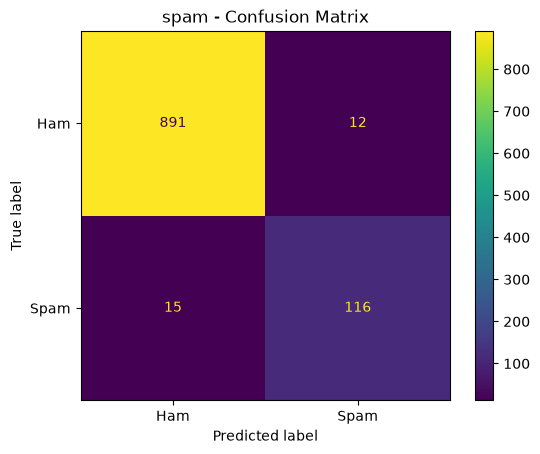

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score

best_name = results.iloc[0]["Model"]
best_pipe = make_text_pipe(text_models[best_name])
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

print("Best model:", best_name)
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))
test_auc = roc_auc_score(y_test, best_pipe.predict_proba(X_test)[:, 1])
print("Test ROC-AUC:", round(test_auc, 3))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Ham", "Spam"])
plt.title("spam - Confusion Matrix")
plt.savefig("../assets/spam_confusion.png", bbox_inches="tight")
plt.show()

results.round(3).to_csv("../assets/spam_results.csv", index=False)

In [5]:
import joblib

joblib.dump({
    "pipeline": best_pipe,
    "model_name": best_name,
    "test_auc": float(test_auc),
}, "../models/spam_model.joblib")
print("Saved ../models/spam_model.joblib")

samples = [
    "Congratulations! Reply WIN now to claim your free gift voucher",
    "Hey, are we still meeting for lunch tomorrow?",
]
for s in samples:
    p = best_pipe.predict_proba([s])[0][1]
    print(f"spam probability {p:.2f} ->", s)

Saved ../models/spam_model.joblib
spam probability 0.95 -> Congratulations! Reply WIN now to claim your free gift voucher
spam probability 0.06 -> Hey, are we still meeting for lunch tomorrow?


In [6]:
import os
print(os.getcwd())
print(os.path.abspath(".."))

C:\Users\dell\OneDrive\Desktop\SPAM-MAIL-DETECTOR\notebooks
C:\Users\dell\OneDrive\Desktop\SPAM-MAIL-DETECTOR
